# Regression analysis - LR Batch Size Combined Variation

## First run - sc4422

### Parameters
wcte_regression.yaml

Overrides: 

data.dataset.transforms=['double_cover'] model.conv_pad_mode='circular' \
tasks.train.data_loaders.train.batch_size=1024 \
tasks.evaluate.data_loaders.test.batch_size=2048 \
tasks.train.data_loaders.validation.batch_size=2048 \
tasks.train.data_loaders.train.pre_transforms=[]


### Data/ Paths

Electron run: \
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/e_FC.npz' \
Muon run: \
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/e_FC.npz' \
data.dataset.geometry_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/geometries/WCTE_geometry_v1.12.21.npz' \
data.dataset.mpmt_positions_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/mpmt_pos_files/WCTE_mpmt_position_correct_251125.npz' \
data.dataset.h5file='/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5'

### Disclaimer

### Outputs
Run directory: /vols/hyperk/users/sc4422/first_run/outputs/regression/electrons/{regression_type}/$DATE

{regression_type} - position, directions, energy

### WatChMaL github version
workshop_2025-91-g158c799

# Setup

In [ ]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [ ]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799


# Processing h5 data

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:
data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [9]:
idxs_path_new_geo_e = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/e_FC.npz"
test_idxs_new_geo_e  = np.load(idxs_path_new_geo_e, allow_pickle=True)['test_idxs']

idxs_path_new_geo_mu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/mu_FC.npz"
test_idxs_new_geo_mu  = np.load(idxs_path_new_geo_mu, allow_pickle=True)['test_idxs']

# idxs_path_new_geo_emu = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_ALL.npz"
# test_idxs_new_geo_emu  = np.load(idxs_path_new_geo_emu, allow_pickle=True)['test_idxs']

In [10]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [11]:
# data_new_geo_emu = get_values(h5_file_new_geo, test_idxs_new_geo_emu)
data_new_geo_mu =  get_values(h5_file_new_geo, test_idxs_new_geo_mu)
data_new_geo_e =  get_values(h5_file_new_geo, test_idxs_new_geo_e)

# Processing fitQun data

In [12]:
# def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
#     N = len(all_event_ids)
#     cut_start_idxs: list[int] = [0]
#     CUTOFF = 500
#     for i in range(N - 1):
#         if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
#             cut_start_idxs.append(i+ 1)
#     cut_start_idxs.append(len(all_event_ids)-1)
#     return cut_start_idxs

# def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
#     missing_ids_fq = []
#     missing_inds_fq = []
#     missing_ids_h5 = []    
#     missing_inds_h5 = []
#     n_cuts = len(fq_cuts)
#     assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
#     for i in range(1, n_cuts):
#         fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
#         h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

#         fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
#         h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

#         assert fq_ids[0] < 100
#         assert fq_ids[-1] > 990

#         missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
#         if len(missing_both) > 0:
#             print(missing_both)

#         missing_fq = np.setdiff1d(fq_ids, h5_ids)
#         inds_fq = np.searchsorted(fq_ids, missing_fq)

#         missing_ids_fq.append(missing_fq.tolist())
#         missing_inds_fq.append(fq_start_idx + inds_fq)


#         missing_h5 = np.setdiff1d(h5_ids, fq_ids)
#         inds_h5 = np.searchsorted(h5_ids, missing_h5)

#         missing_ids_h5.append(missing_h5.tolist())
#         missing_inds_h5.append(h5_start_idx + inds_h5)
    
#     return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [13]:
# # fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# # fq = FiTQunOutput(fitqun_files_full)

# fitqun_files_mu = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_mu-_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_mu)

In [14]:
# #Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
# fq_event_ids = fq.chain['nevt'] #.compute()
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo_emu['event_ids']

# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)

# print("fq cuts:", len(fq_cuts), fq_cuts[:10], fq_cuts[-3:])
# print("h5 cuts:", len(h5_cuts), h5_cuts[:10], h5_cuts[-3:])

# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))


# # for fc no missing indices so should just use the original one directional code

In [15]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo_emu['event_ids'])), missing_indices_h5)

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo_emu['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo_emu['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
# h5_electron_flag = fq.electron_flag
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
# h5_muon_flag = fq.muon_flag#.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# fc_cut = data_new_geo_emu['fc'][h5_keep_idx]
# mu_cut = data_new_geo_emu['labels'][h5_keep_idx]==2
# el_cut = data_new_geo_emu['labels'][h5_keep_idx]==1

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [17]:
# mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# fq_mu_nll = mu_mu - el_mu
# fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [18]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [19]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo_mu = apply_cuts(data_new_geo_mu)
cuts_new_geo_e = apply_cuts(data_new_geo_e)

In [20]:
e_idxs_new_geo = data_new_geo_e['labels']==1
mu_idxs_new_geo = data_new_geo_mu['labels']==2

In [21]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [22]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo_e, 1, cuts_new_geo_e)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo_mu, 2, cuts_new_geo_mu)

In [23]:
resnet_args = {'linestyle':"-"}
electron_args_new_geo = {'indices':test_idxs_new_geo_e[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo_mu[mu_idxs_new_geo],'selection':mu_cuts} # still selection for the physical cuts

#muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts} # trying to convert “muon rows inside the test subset” into “global H5 row indices” for the output dir

# Loading ResNet results

In [24]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/regression/"

In [25]:
# cuts_new_geo_emu = apply_cuts(data_new_geo_emu)
# e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo_emu, 1, cuts_new_geo_emu)
# mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo_emu, 2, cuts_new_geo_emu)

In [26]:
# # # output_energy = "2026-02-05/18-30-30"
# # # output_pos = "2026-02-05/21-17-54"
# # # output_dir = ""

# # output_pos_mu = 'muons/position/2026-02-12/17-14-12/'
# # output_pos_e = 'electrons/position/2026-02-12/10-36-01/'

# # output_dir_mu = 'muons/directions/2026-02-12/16-11-11/'
# # output_dir_e = 'electrons/directions/2026-02-12/11-27-55/'


# output_pos_mu = 'muons/position/2026-02-17/11-01-24/'
# output_pos_e = 'electrons/position/2026-02-17/11-00-22/'

# output_dir_mu = 'muons/directions/2026-02-17/11-30-33/'
# output_dir_e = 'electrons/directions/2026-02-17/11-29-33/'

# # output_energy_mu = 'muons/energy/2026-02-12/18-14-04/'

# output_energy_mu = 'muons/energy/2026-02-17/00-01-04/'

# # output_energy_e = 'electrons/energy/2026-02-12/14-24-01/'

# output_energy_e = 'electrons/energy/2026-02-17/11-51-58/'


# output_mu_lr02 = 'muons/lr/2026-02-24/16-36-21'
# #output_e_lr02 = 'electrons/lr/2026-02-24/14-37-38'

# output_mu_lr05 = 'muons/lr/2026-02-24/16-35-02'
# output_e_lr05 = 'electrons/lr/2026-02-24/14-36-31'

# output_mu_lr002 = 'muons/lr/2026-02-24/17-09-11'
# output_e_lr002 = 'electrons/lr/2026-02-24/14-40-32'

# output_mu_lr001 = 'muons/lr/2026-02-24/17-09-05'
# output_e_lr001 ='electrons/lr/2026-02-24/15-21-00'

# output_mu_lr0015 = 'muons/lr/2026-03-03/09-51-37'
# output_e_lr0015 = 'electrons/lr/2026-03-03/09-50-48'

# output_mu_lr00225 = 'muons/lr/2026-03-03/09-51-41'

# resnet_muon_pos = [
#     WatChMaLPositionRegression(outdir_reg+output_mu_lr05, "ResNet50 Muon Position LR 0.05 BS 2048", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+output_mu_lr02, "ResNet50 Muon Position LR 0.02 BS 2048", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+output_mu_lr002, "ResNet50 Muon Position LR 0.002 BS 1024", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+output_mu_lr001, "ResNet50 Muon Position LR 0.001 BS 512", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
# ]
# resnet_e_pos =  [
#     WatChMaLPositionRegression(outdir_reg+output_e_lr05, "ResNet50 Electron Position LR 0.05 BS 2048", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     #WatChMaLPositionRegression(outdir_reg+output_e_lr02, "ResNet50 Electron Position LR 0.02 BS 2048", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+output_e_lr002, "ResNet50 Electron Position LR 0.002 BS 1024", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg+output_e_lr001, "ResNet50 Electron Position LR 0.001 BS 512", e_pos, e_dir, **electron_args_new_geo, **resnet_args)
# ]

# ### Dir

# resnet_muon_dir = [
#     WatChMaLDirectionRegression(outdir_reg+output_mu_lr05, "ResNet 50 Muon Direction LR 0.05 BS 2048", mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg+output_mu_lr02, "ResNet 50 Muon Direction LR 0.02 BS 2048", mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg+output_mu_lr002, "ResNet 50 Muon Direction LR 0.002 BS 1024", mu_dir, **muon_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg+output_mu_lr001, "ResNet 50 Muon Direction LR 0.001 BS 512", mu_dir, **muon_args_new_geo, **resnet_args)
# ]
# resnet_e_dir = [
#     WatChMaLDirectionRegression(outdir_reg+output_e_lr05, "ResNet50 Electron Direction LR 0.05 BS 2048", e_dir, **electron_args_new_geo, **resnet_args),
#     #WatChMaLDirectionRegression(outdir_reg+output_e_lr02, "ResNet50 Electron Direction LR 0.02 BS 2048", e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg+output_e_lr002, "ResNet50 Electron Direction LR 0.002 BS 1024", e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg+output_e_lr001, "ResNet50 Electron Direction LR 0.001 BS 512", e_dir, **electron_args_new_geo, **resnet_args)
# ]

# ### Energy

# resnet_muon_energy = [
#     WatChMaLEnergyRegression(outdir_reg+output_mu_lr05, "ResNet 50 Muon Energy LR 0.05 BS 2048", mu_mom,2, **muon_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output_mu_lr02, "ResNet 50 Muon Energy LR 0.02 BS 2048", mu_mom,2, **muon_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output_mu_lr002, "ResNet 50 Muon Energy LR 0.002 BS 1024", mu_mom,2, **muon_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output_mu_lr001, "ResNet 50 Muon Energy LR 0.001 BS 512", mu_mom,2, **muon_args_new_geo, **resnet_args)
# ]
# resnet_e_energy = [
#     WatChMaLEnergyRegression(outdir_reg+output_e_lr05, "ResNet 50 Electron Energy LR 0.05 BS 2048", e_mom, 1, **electron_args_new_geo, **resnet_args),
#     #WatChMaLEnergyRegression(outdir_reg+output_e_lr02, "ResNet 50 Electron Energy LR 0.02 BS 2048", e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output_e_lr002, "ResNet 50 Electron Energy LR 0.002 BS 1024", e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg+output_e_lr001, "ResNet 50 Electron Energy LR 0.001 BS 512", e_mom, 1, **electron_args_new_geo, **resnet_args)
# ]

In [27]:
output_mu_lr02 = 'muons/lr/2026-02-24/16-36-21'
#output_e_lr02 = 'electrons/lr/2026-02-24/14-37-38'

output_mu_lr05 = 'muons/lr/2026-02-24/16-35-02'
output_e_lr05 = 'electrons/lr/2026-02-24/14-36-31'

output_mu_lr002 = 'muons/lr/2026-02-24/17-09-11'
output_e_lr002 = 'electrons/lr/2026-02-24/14-40-32'

output_mu_lr001 = 'muons/lr/2026-02-24/17-09-05'
output_e_lr001 = 'electrons/lr/2026-02-24/15-21-00'

output_mu_lr0015 = 'muons/lr/2026-03-03/09-51-37'
output_e_lr0015 = 'electrons/lr/2026-03-03/09-50-48'

output_mu_lr00225 = 'muons/lr/2026-03-03/09-51-41'
# (missing in your snippet; add if you have it)
# output_e_lr00225 = 'electrons/lr/2026-03-03/??-??-??'

resnet_muon_pos = [
    WatChMaLPositionRegression(outdir_reg+output_mu_lr05,   "ResNet50 Muon Position LR 0.05 BS 1024",   mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_lr02,   "ResNet50 Muon Position LR 0.02 BS 1024",   mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_lr002,  "ResNet50 Muon Position LR 0.002 BS 1024",  mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_lr001,  "ResNet50 Muon Position LR 0.001 BS 1024",  mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_lr0015, "ResNet50 Muon Position LR 0.0015 BS 1024", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_mu_lr00225,"ResNet50 Muon Position LR 0.00225 BS 1024",mu_pos, mu_dir, **muon_args_new_geo, **resnet_args),
]

resnet_e_pos = [
    WatChMaLPositionRegression(outdir_reg+output_e_lr05,   "ResNet50 Electron Position LR 0.05 BS 1024",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    #WatChMaLPositionRegression(outdir_reg+output_e_lr02,   "ResNet50 Electron Position LR 0.02 BS 1024",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_e_lr002,  "ResNet50 Electron Position LR 0.002 BS 1024",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_e_lr001,  "ResNet50 Electron Position LR 0.001 BS 1024",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg+output_e_lr0015, "ResNet50 Electron Position LR 0.0015 BS 1024", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    #WatChMaLPositionRegression(outdir_reg+output_e_lr00225,"ResNet50 Electron Position LR 0.00225 BS 1024",e_pos, e_dir, **electron_args_new_geo, **resnet_args),
]

### Dir

resnet_muon_dir = [
    WatChMaLDirectionRegression(outdir_reg+output_mu_lr05,   "ResNet 50 Muon Direction LR 0.05 BS 1024",   mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_lr02,   "ResNet 50 Muon Direction LR 0.02 BS 1024",   mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_lr002,  "ResNet 50 Muon Direction LR 0.002 BS 1024",  mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_lr001,  "ResNet 50 Muon Direction LR 0.001 BS 1024",  mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_lr0015, "ResNet 50 Muon Direction LR 0.0015 BS 1024", mu_dir, **muon_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_mu_lr00225,"ResNet 50 Muon Direction LR 0.00225 BS 1024",mu_dir, **muon_args_new_geo, **resnet_args),
]

resnet_e_dir = [
    WatChMaLDirectionRegression(outdir_reg+output_e_lr05,   "ResNet50 Electron Direction LR 0.05 BS 1024",   e_dir, **electron_args_new_geo, **resnet_args),
    #WatChMaLDirectionRegression(outdir_reg+output_e_lr02,   "ResNet50 Electron Direction LR 0.02 BS 1024",   e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_e_lr002,  "ResNet50 Electron Direction LR 0.002 BS 1024",  e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_e_lr001,  "ResNet50 Electron Direction LR 0.001 BS 1024",  e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg+output_e_lr0015, "ResNet50 Electron Direction LR 0.0015 BS 1024", e_dir, **electron_args_new_geo, **resnet_args),
    #WatChMaLDirectionRegression(outdir_reg+output_e_lr00225,"ResNet50 Electron Direction LR 0.00225 BS 1024",e_dir, **electron_args_new_geo, **resnet_args),
]

### Energy

resnet_muon_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_mu_lr05,   "ResNet 50 Muon Energy LR 0.05 BS 1024",   mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_lr02,   "ResNet 50 Muon Energy LR 0.02 BS 1024",   mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_lr002,  "ResNet 50 Muon Energy LR 0.002 BS 1024",  mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_lr001,  "ResNet 50 Muon Energy LR 0.001 BS 1024",  mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_lr0015, "ResNet 50 Muon Energy LR 0.0015 BS 1024", mu_mom, 2, **muon_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_mu_lr00225,"ResNet 50 Muon Energy LR 0.00225 BS 1024",mu_mom, 2, **muon_args_new_geo, **resnet_args),
]

resnet_e_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_e_lr05,   "ResNet 50 Electron Energy LR 0.05 BS 1024",   e_mom, 1, **electron_args_new_geo, **resnet_args),
    #WatChMaLEnergyRegression(outdir_reg+output_e_lr02,   "ResNet 50 Electron Energy LR 0.02 BS 1024",   e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_e_lr002,  "ResNet 50 Electron Energy LR 0.002 BS 1024",  e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_e_lr001,  "ResNet 50 Electron Energy LR 0.001 BS 1024",  e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg+output_e_lr0015, "ResNet 50 Electron Energy LR 0.0015 BS 1024", e_mom, 1, **electron_args_new_geo, **resnet_args),
    #WatChMaLEnergyRegression(outdir_reg+output_e_lr00225,"ResNet 50 Electron Energy LR 0.00225 BS 1024",e_mom, 1, **electron_args_new_geo, **resnet_args),
]

/vols/hyperk/users/sc4422/first_run/WatChMaL/watchmal/utils/math.py:95: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(energy**2 - mass**2)


# Plot training progression

In [28]:
# for r in resnet_muon_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')

# # for r in resnet_muon_energy:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# # for r in resnet_e_position:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
# for r in resnet_e_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

ValueError: Some errors were detected !
    Line #12 (got 17 columns instead of 7)
    Line #12531 (got 4 columns instead of 7)

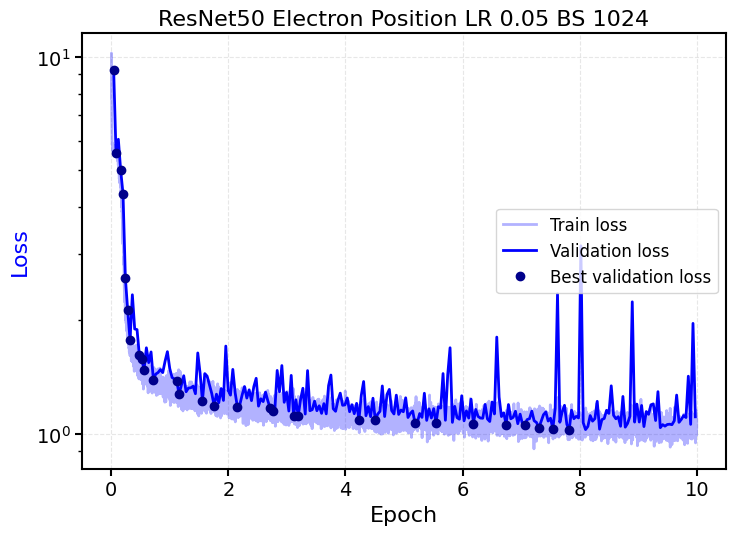

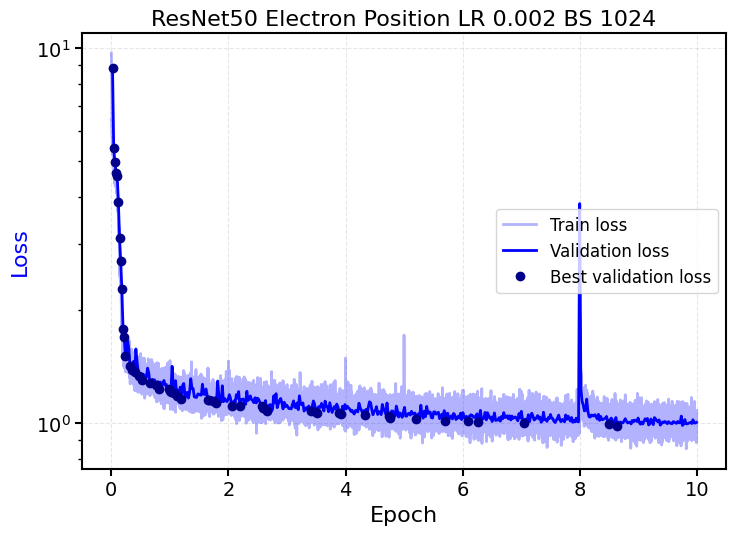

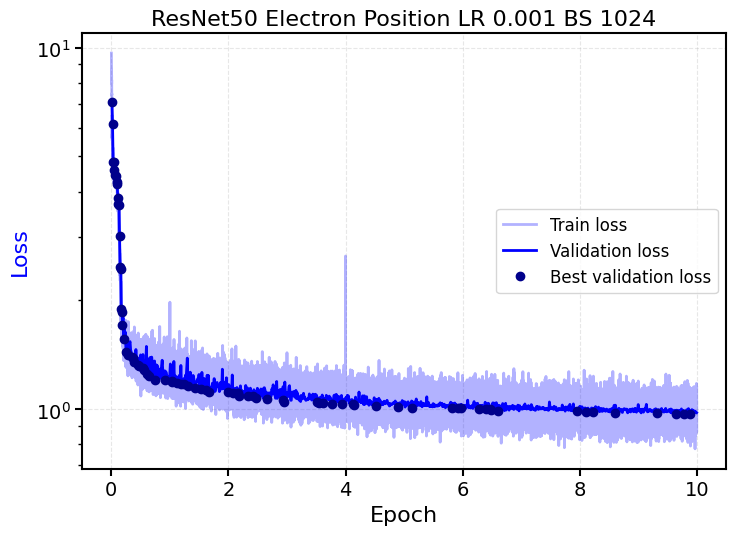

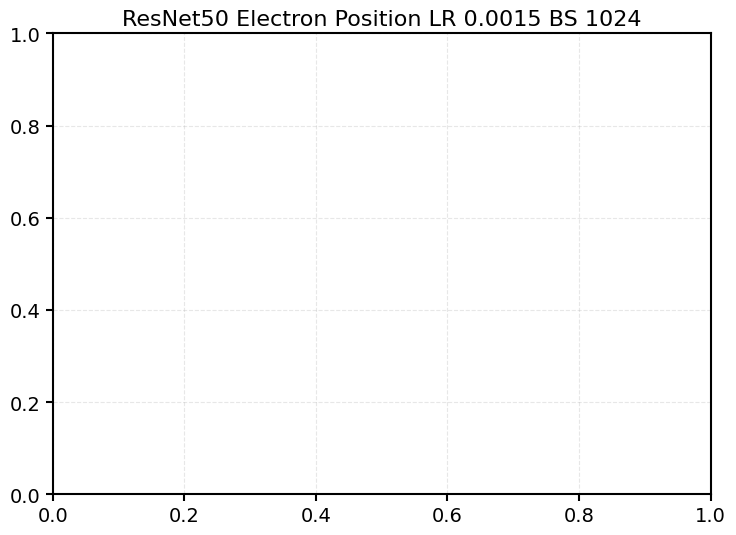

In [29]:
for r in resnet_e_pos:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')

# Statistics

In [30]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']

tabulate_statistics(resnet_muon_pos, position_stats, position_stat_labels, position_stat_types)


# 0.005 and 0.05 exact same for some reason?

,ResNet50 Muon Position LR 0.05 BS 1024,ResNet50 Muon Position LR 0.02 BS 1024,ResNet50 Muon Position LR 0.002 BS 1024,ResNet50 Muon Position LR 0.001 BS 1024,ResNet50 Muon Position LR 0.0015 BS 1024,ResNet50 Muon Position LR 0.00225 BS 1024
x position resolution [cm],4.96,4.38,3.91,3.59,4.21,4.69
y position resolution [cm],4.88,4.11,3.98,3.63,4.36,4.78
z position resolution [cm],4.74,4.91,3.84,3.61,3.85,4.65
3D position resolution [cm],9.12,8.48,7.41,6.89,7.84,8.89
Transverse position resolution [cm],7.45,7.37,6.45,5.96,6.54,7.41
Longitudinal position resolution [cm],4.75,3.64,3.20,2.97,3.96,4.38
Longitudinal position mean bias [cm],-1.75,0.59,0.37,0.14,-1.91,-1.85


In [31]:
tabulate_statistics(resnet_e_pos, position_stats, position_stat_labels, position_stat_types)

,ResNet50 Electron Position LR 0.05 BS 1024,ResNet50 Electron Position LR 0.002 BS 1024,ResNet50 Electron Position LR 0.001 BS 1024,ResNet50 Electron Position LR 0.0015 BS 1024
x position resolution [cm],4.49,3.97,3.91,4.26
y position resolution [cm],4.38,4.09,3.85,4.36
z position resolution [cm],4.51,4.05,3.93,4.55
3D position resolution [cm],8.46,7.67,7.42,8.30
Transverse position resolution [cm],6.21,5.60,5.44,6.17
Longitudinal position resolution [cm],5.13,4.68,4.46,4.98
Longitudinal position mean bias [cm],-0.69,0.89,0.08,0.87


In [32]:
#hostname
energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ["energy_residuals", 'momentum_residuals', "energy_residuals", 'momentum_residuals', 'energy_percentage_errors', 'momentum_percentage_errors','energy_percentage_errors', 'momentum_percentage_errors']
energy_stat_types = ['resolution', 'resolution', 'mean','mean', 'resolution', 'resolution','mean','mean',]

# r = resnet_muon_energy[0]
# valid = np.asarray(r.predictions) >= 105.7

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet 50 Muon Energy LR 0.05 BS 1024,ResNet 50 Muon Energy LR 0.02 BS 1024,ResNet 50 Muon Energy LR 0.002 BS 1024,ResNet 50 Muon Energy LR 0.001 BS 1024,ResNet 50 Muon Energy LR 0.0015 BS 1024,ResNet 50 Muon Energy LR 0.00225 BS 1024
energy_residuals,7.08,7.21,6.79,6.32,6.95,7.01
momentum_residuals,7.50,7.67,7.20,6.70,7.35,7.42
energy_residuals,0.60,-1.71,1.06,-0.28,0.66,-0.44
momentum_residuals,0.61,-1.85,1.12,-0.28,0.74,-0.46
energy_percentage_errors,1.97,2.03,1.89,1.76,1.94,1.94
momentum_percentage_errors,2.23,2.30,2.15,1.99,2.20,2.20
energy_percentage_errors,0.19,-0.53,0.32,0.00,0.37,-0.04
momentum_percentage_errors,0.19,-0.65,0.38,0.01,0.43,-0.05


In [33]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet 50 Electron Energy LR 0.05 BS 1024,ResNet 50 Electron Energy LR 0.002 BS 1024,ResNet 50 Electron Energy LR 0.001 BS 1024,ResNet 50 Electron Energy LR 0.0015 BS 1024
energy_residuals,nan,nan,23.28,nan
momentum_residuals,nan,nan,23.28,nan
energy_residuals,nan,nan,-15.94,nan
momentum_residuals,nan,nan,-15.94,nan
energy_percentage_errors,nan,nan,8.66,nan
momentum_percentage_errors,nan,nan,8.66,nan
energy_percentage_errors,nan,nan,-1.59,nan
momentum_percentage_errors,nan,nan,-1.59,nan


In [34]:
# Direction statistics

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_dir, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet 50 Muon Direction LR 0.05 BS 1024,ResNet 50 Muon Direction LR 0.02 BS 1024,ResNet 50 Muon Direction LR 0.002 BS 1024,ResNet 50 Muon Direction LR 0.001 BS 1024,ResNet 50 Muon Direction LR 0.0015 BS 1024,ResNet 50 Muon Direction LR 0.00225 BS 1024
Direction residual error,2.88,2.77,2.46,2.42,2.54,3.55


In [35]:
tabulate_statistics(resnet_e_dir, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet50 Electron Direction LR 0.05 BS 1024,ResNet50 Electron Direction LR 0.002 BS 1024,ResNet50 Electron Direction LR 0.001 BS 1024,ResNet50 Electron Direction LR 0.0015 BS 1024
Direction residual error,4.40,4.00,3.78,4.05


# Plots

In [36]:
# print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
# print(len(mu_pos[mu_cuts]))

# A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# print(len(A), len(B))
# print(np.array_equal(A, B))                 # identical set + order
# print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


### Muon Plots

In [37]:
# from matplotlib.ticker import MaxNLocator, LogLocator
# import matplotlib
# import matplotlib.pyplot as plt

# matplotlib.rcParams.update({
#     'axes.labelsize': 15,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })

# labels = np.asarray(data_new_geo_emu["labels"]).astype(int)

# mu_mask = labels == 2

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo_emu["positions"][h5_keep_idx][mu_mask],
#     true_directions=data_new_geo_emu["directions"][h5_keep_idx][mu_mask],
#     true_momenta=data_new_geo_emu["momentum"][h5_keep_idx][mu_mask],
#     true_labels=2,                        
#     indices=fq_keep_idx[mu_mask],       
#     selection=cuts_new_geo_mu,
# )

muon_mom_binning = get_binning(data_new_geo_mu["momentum"], 20, 0, 1000)
muon_cos_zenith_binning = get_binning(np.cos(data_new_geo_mu["angles"][:,0]), 20, -1, 1)

muon_azimuth_binning = get_binning(data_new_geo_mu["angles"][:,1] * 180 / np.pi, 20, -180, 180)

muon_dwall_binning = get_binning(data_new_geo_mu["dwall"], 22, 50, 300)

muon_towall_binning = get_binning(data_new_geo_mu["towall"], 30, 50, 800)

In [38]:
all_runs_pos = resnet_muon_position #+ [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Position resolution [cm]",legend=None)


NameError: name 'resnet_muon_position' is not defined

In [ ]:
all_runs_mom =  resnet_muon_energy #+ [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Momentum resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Momentum resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Momentum resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position Momentum",legend=None)
    plot_resolution_profile([r],'momentum_residuals',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Momentum resolution",legend=None)


In [ ]:
all_runs_dir =  resnet_muon_direction #+ [fitqun_mu]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', muon_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', muon_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', muon_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',muon_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors',muon_mom_binning, ax=axes[2,0],x_label="True muon momentum [MeV]",y_label="Direction resolution",legend=None)


/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1555: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


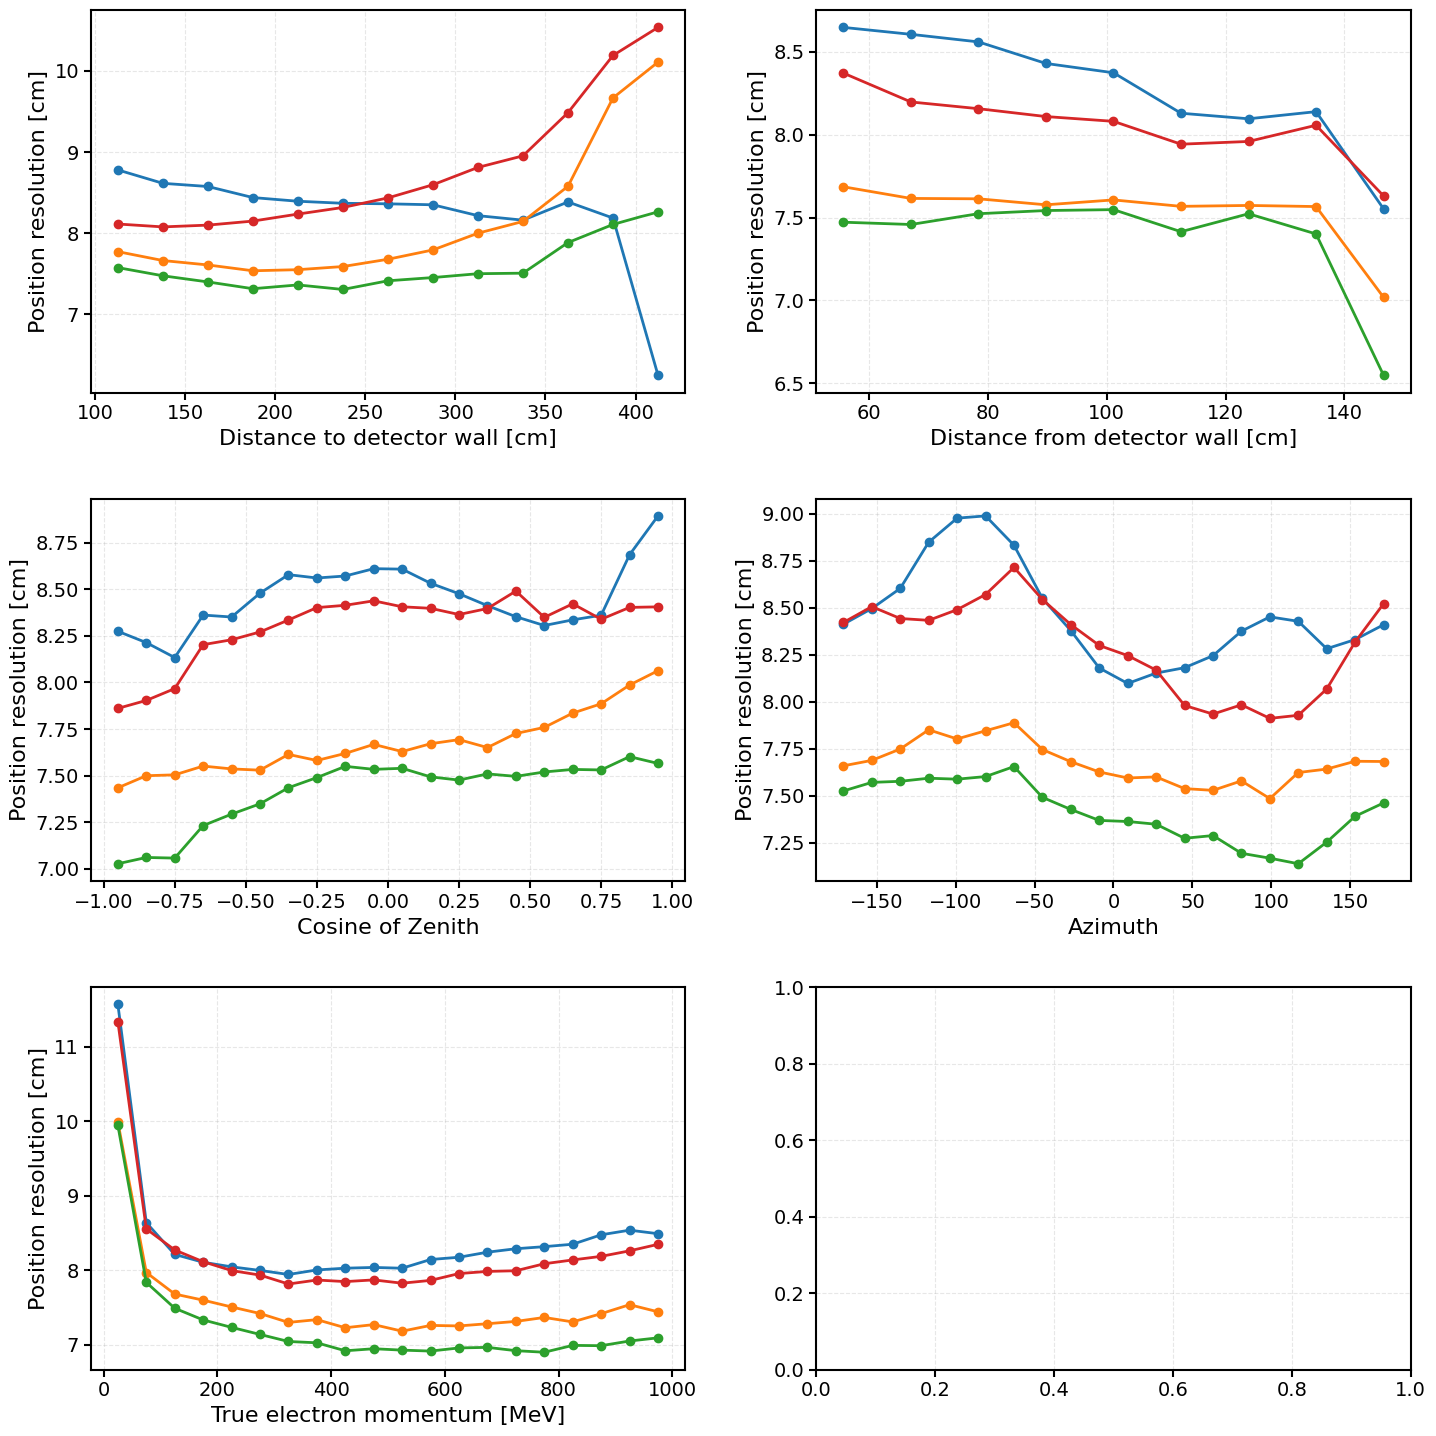

In [39]:
# e_mask = labels == 1

# fitqun_e = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo_emu["positions"][h5_keep_idx][e_mask],
#     true_directions=data_new_geo_emu["directions"][h5_keep_idx][e_mask],
#     true_momenta=data_new_geo_emu["momentum"][h5_keep_idx][e_mask],
#     true_labels=1,                        
#     indices=fq_keep_idx[e_mask],       
#     selection=cuts_new_geo_e,
# )

e_mom_binning = get_binning(data_new_geo_e["momentum"], 20, 0, 1000)

e_cos_zenith_binning = get_binning(np.cos(data_new_geo_e["angles"][:,0]), 20, -1, 1)

e_azimuth_binning = get_binning(data_new_geo_e["angles"][:,1] * 180 / np.pi, 20, -180, 180)

e_dwall_binning = get_binning(data_new_geo_e["dwall"], 22, 50, 300)

e_towall_binning = get_binning(data_new_geo_e["towall"], 30, 50, 800)

all_runs_pos = resnet_e_pos #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None)

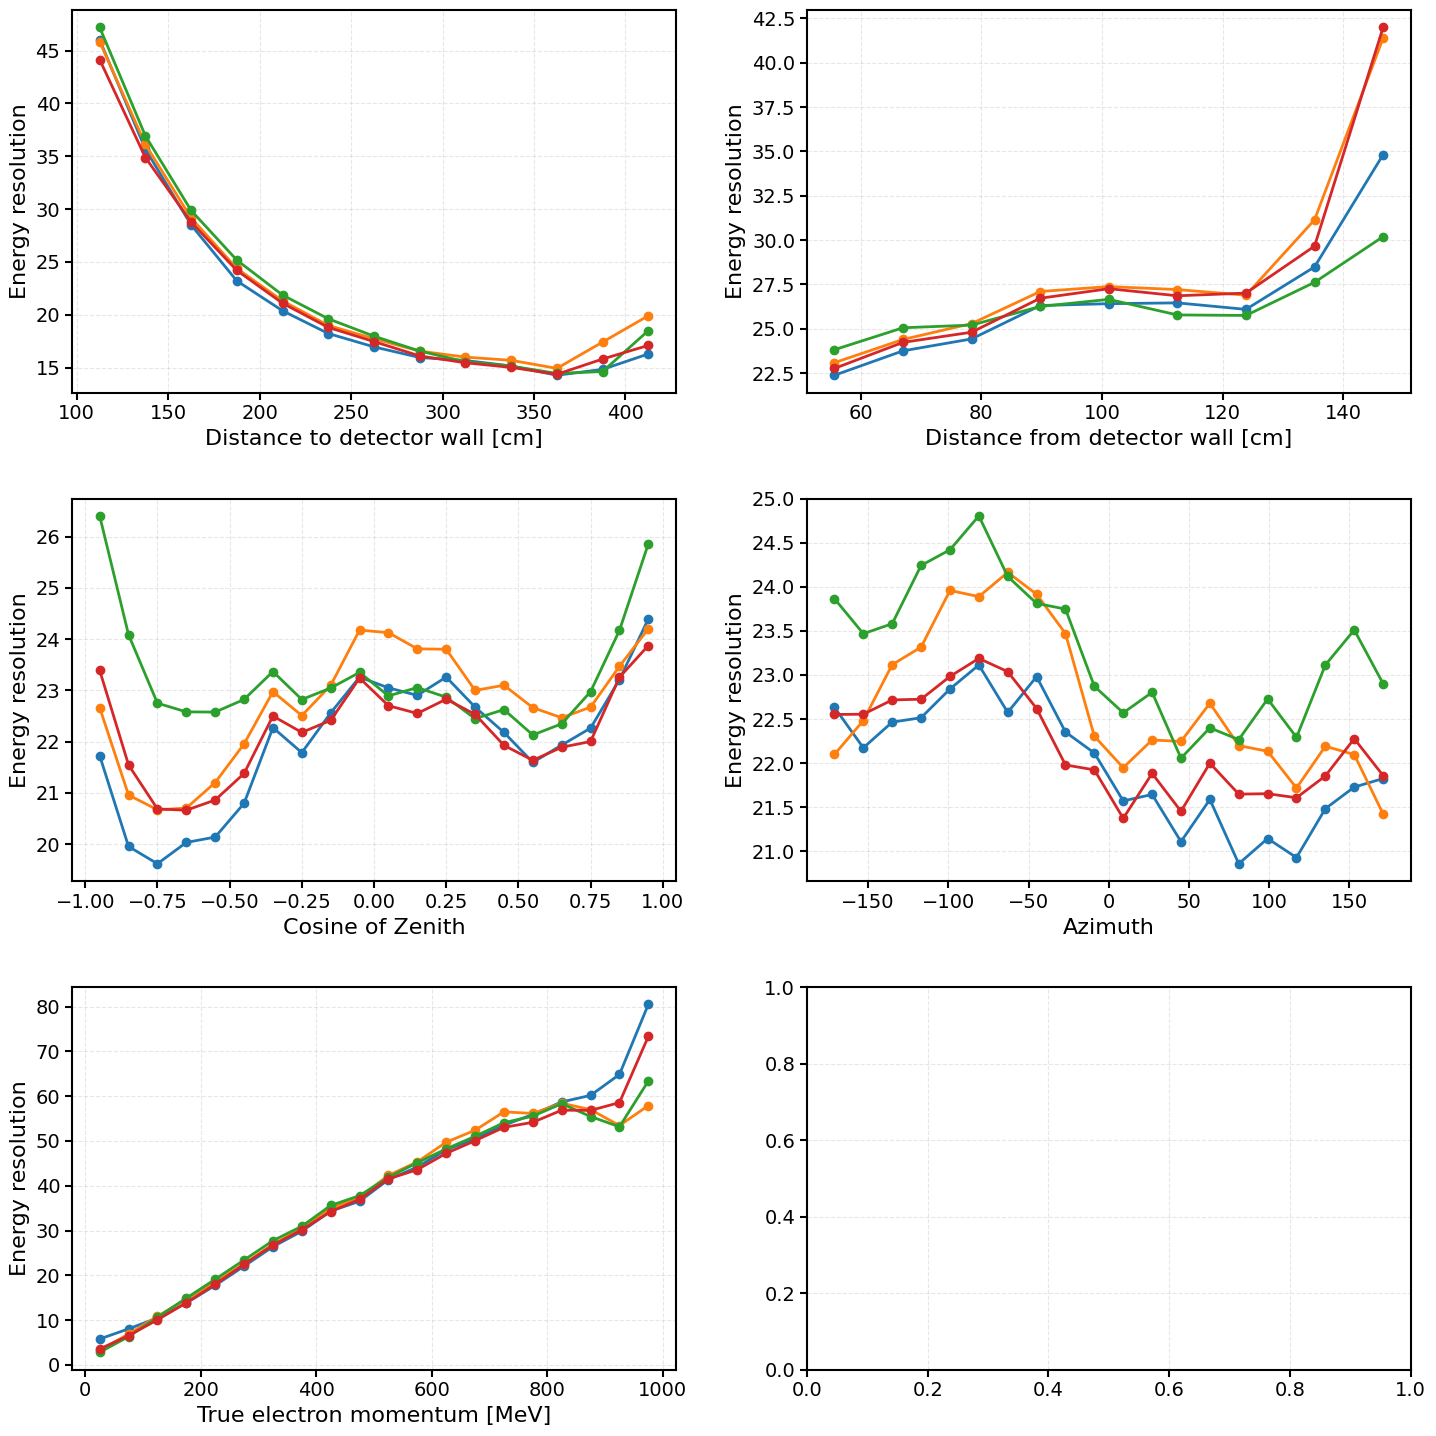

In [40]:
all_runs_mom =  resnet_e_energy #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Energy resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Energy resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Energy resolution",legend=None)

In [41]:
all_runs_dir =  resnet_e_direction #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)

NameError: name 'resnet_e_direction' is not defined

In [ ]:
## seems like the separate oens are worse?

# also plot more condensed and define as a func maybe